<a href="https://colab.research.google.com/github/zian25-dtanalyst/mobility-economic/blob/main/s5_ladb_mobility_economy_project_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
    

</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>


## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [ ]:
# importar librerías # se preparan las librerias que se usaran a lo largo del desarrollo del proyecto
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv') #indices de trafico
eco = pd.read_csv('/datasets/oecd_city_economy.csv') #tabla de economia

In [ ]:
# mostrar la tabla traffic para entender su estructura
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


Se muesta las primeras 5 lineas de datos de la tabla traffic esto nos da una idea de la estructura de los datos aunque mas adelante se analizara con detalles

**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [ ]:
# Examinar la estructura de traffic
traffic.info(3)
traffic


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016
...,...,...,...,...,...,...,...,...,...,...,...,...
1004459,ZAF,pretoria,2024-10-01 12:31:30.000,195.1,27.0,27.2,66.0,14.0,2024-09-24 12:01:30.001,14.930880,14.129215,0.801665
1004460,ZAF,pretoria,2024-10-01 11:31:30.000,78.3,22.0,9.2,27.0,15.0,2024-09-24 11:01:30.000,13.973285,13.630819,0.342466
1004461,ZAF,pretoria,2024-10-01 10:01:30.000,85.0,21.0,9.7,29.0,16.0,2024-09-24 10:16:30.001,13.690491,13.287302,0.403189
1004462,ZAF,pretoria,2024-10-01 09:01:30.000,68.1,20.0,6.7,23.0,15.0,2024-09-24 09:46:30.000,13.387203,12.983558,0.403646


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo date y son claves para calculos asi como la columa jamsDelay
- Tambien se observa que no hay datos faltantes lo que resultara en un analisis mas precisos ya que los datos son concistentes
- Este data set esta compuesto de 12 columnas y 1,004,464 de celdas con informacion.

In [ ]:
# Examinar la estructura de eco
eco.info(3)
eco

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"
5,2023,fortaleza,Brazil,"838,00",12.5%,"15,40","4,20"
6,2023,belo-horizonte,Brazil,"10.951,00",10.1%,"17,50","6,00"
7,2023,curitiba,Brazil,"12.189,00",8.8%,"14,20","3,60"
8,2023,recife,Brazil,"9.047,00",11.8%,"16,50","4,10"
9,2023,porto-alegre,Brazil,"11.618,00",9.2%,"14,90","4,30"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, tienen datos tipo FLOAT que representan numeros con decimales
- Tambien la columna City GDP/capita presenta datos importante para llegar a conclusiones en este proyecto
- En la tabla eco no existen valores faltantes, lo cual vuelve el analisis mas preciso.
- El data set de economia presenta 7 columnas y 30 entradas de celdas de informacion.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`-
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:
# Estandarizar los nombres de las columnas de traffic
# se usa esta funcion ya que se unifican los nombres de las columnas de una manera mas automatizada dando formato para minusculas y eliminando caracteres especiales
def to_snake_case(name):
    # Paso 1: Insertar _ antes de mayúsculas que siguen a minúsculas
    name = re.sub('([a-z0-9])([A-Z])', r'\1_\2', name)
    # Paso 2: Insertar _ antes de la última mayúscula en una secuencia
    name = re.sub('([A-Z])([A-Z][a-z])', r'\1_\2', name)
    return name.lower()
traffic.columns = [to_snake_case(col) for col in traffic.columns]
# verificar cambios
traffic.columns


Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per10_kms_mins',
       'travel_time_historic_per10_kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
#para dar formato en la tabla eco se uso la funcion rename es util para data sets que no contienen tantas columnas y se puede perzonalizar cada nombre de las columnas
eco = eco.rename(columns={
    'City GDP/capita': 'city_gdp_per_capita',
    'Unemployment %': 'unemployment_pct',
    'PM2.5 (μg/m³)': 'pm25_ug_per_m3',
    'Population (M)': 'population_m',
    'Year':'year','City':'city','Country':'country'
})
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_per_capita', 'unemployment_pct',
       'pm25_ug_per_m3', 'population_m'],
      dtype='object')

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Buena manera de usar expresiones regulares para cambiar el nombre de las columnas, así como bueno el ejemplo en el segundo caso haciendolo de una manera más tradicional
</div>



### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc']) #tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'])
#antes de hacer calculos es importante unificar los tipos de datos en una sola columna de esta manera los resultados seran los mas precisos
# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per10_kms_mins      1004464 non-null  fl

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_per_capita'] = eco['city_gdp_per_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 30 non-null     int64  
 1   city                 30 non-null     object 
 2   country              30 non-null     object 
 3   city_gdp_per_capita  30 non-null     float64
 4   unemployment_pct     30 non-null     float64
 5   pm25_ug_per_m3       30 non-null     object 
 6   population_m         30 non-null     float64
 7   population           30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_per_capita,unemployment_pct,pm25_ug_per_m3,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Los datos fueron revisados y modificados apropiadamente, ahora se puede empezar a trabajar con ellos comodamente
</div>



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
#se crea una nueva columna para filtrar solo el año que nos interesa analizar
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year
# Verificar cambio
traffic.head(3)


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_per_capita,unemployment_pct,pm25_ug_per_m3,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Buena manera de extraer el año y de filtrar los datos, ahora podemos trabajar con los datos requeridos
</div>



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:
#el calculo de los datos es un paso importante para nuestro analisis esta celda nos ayuda a promediar los datos de columnas especificas
# Calcular los  promedios de trafico por ciudad, país y año
# Calcular los promedios de tráfico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year']).agg({
    'jams_delay': 'mean',
    'traffic_index_live': 'mean',
    'jams_length_in_kms': 'mean',  # ← Aquí estaba el error
    'jams_count': 'mean',
    'mins_delay': 'mean',
    'travel_time_live_per10_kms_mins': 'mean',
    'travel_time_historic_per10_kms_mins': 'mean'
}).reset_index()

# Mostrar resultado
traffic_city_year_2024.head()


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Excelente!<br/>

Has tomado las columnas correctas para hacer la agrupación del conjunto de datos, podemos ver ahora en las columnas los promedios de cada una de las ciudades
</div>


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)
#ordenar de mayor a menor utilizando los promedios de la columna jams:delay nos muestra que ciudad es la que contiene el mayor tiempo promedio de trafico

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es Ciuedad de Mexico, ya que se pierde aproximadamente 2 dias en traslados y congestionamiento del trafico, es importante destacar que esto es una muestra de todas las unidades monitoreadas no representa una muestra por persona pero si es importante para entender el impacto economico estimado que puede tener esta perdida de tiempo en dicha ciudad y pais.


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:
#Finalmente se unifican los data sets seleccionando solo las columnas que son relevantes para nuestro analisis
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per10_kms_mins','travel_time_historic_per10_kms_mins']

right_cols = ['city','year','city_gdp_per_capita','unemployment_pct','pm25_ug_per_m3','population']

# Usar .copy() para crear los dos nuevos datasets reducidos

traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar las primeras 5 filas
merged.head(5)


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins,city_gdp_per_capita,unemployment_pct,pm25_ug_per_m3,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>

La union de los datos se hizo de una buena manera al tomar solo las columnas necesarias de cada uno de los conjuntos de datos
</div>



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

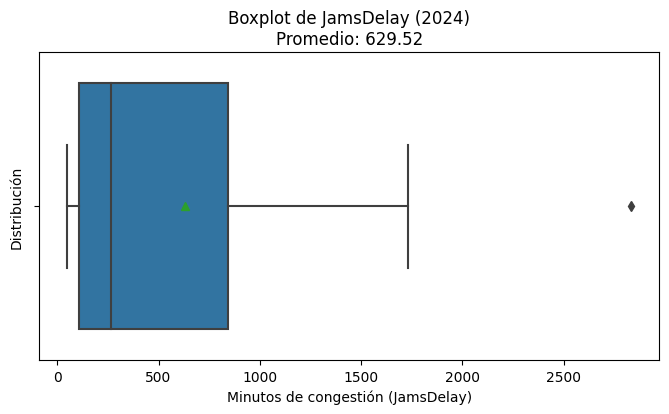

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
plt.figure(figsize=(8, 4))
sns.boxplot(data=merged, x='jams_delay', showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.xlabel('Minutos de congestión (JamsDelay)')
plt.ylabel('Distribución')
plt.show()



Segun el boxplot ejecutado sobre la columna jamsdelay, basandos en el promedio de la misma nos encontramos ante un valor atipico que se sale del rango promedio, analizando la tabla nos damos cuenta que este valor pertenece a la ciuadad de mexico el cual no representa un dato incorrecto, ya que por las caracteristicas de esta ciudad es bastante certera esta informacion en cuando al tiempo de retraso en el trafico en minutos.

In [ ]:
# se agrega esta vista para analizar mejor el hallazgo del valor atipico que arrojo nuestro boxplot
# Calcular cuartiles y rango intercuartílico (IQR)
Q1 = merged['jams_delay'].quantile(0.25)
Q3 = merged['jams_delay'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites para valores atípicos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar valores atípicos
outliers = merged[(merged['jams_delay'] < limite_inferior) |
                  (merged['jams_delay'] > limite_superior)]

# Contar valores atípicos
num_outliers = len(outliers)
print(f"Número total de valores atípicos: {num_outliers}")
print(f"Valores atípicos superiores: {len(merged[merged['jams_delay'] > limite_superior])}")
print(f"Valores atípicos inferiores: {len(merged[merged['jams_delay'] < limite_inferior])}")

# Ver qué ciudades son valores atípicos
print("\nCiudades con valores atípicos:")
print(outliers[['city', 'jams_delay']])

Número total de valores atípicos: 1
Valores atípicos superiores: 1
Valores atípicos inferiores: 0

Ciudades con valores atípicos:
          city   jams_delay
7  mexico-city  2833.057892


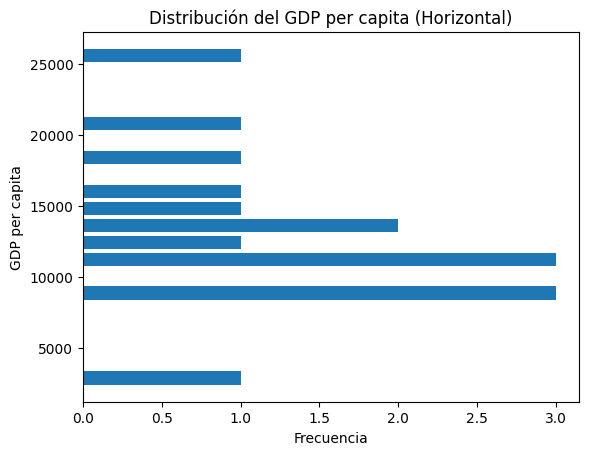

In [ ]:
counts, bins = np.histogram(merged['city_gdp_per_capita'], bins=20)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Crear gráfico horizontal
plt.barh(bin_centers, counts, height=(bins[1] - bins[0]) * 0.8)
plt.xlabel('Frecuencia')
plt.ylabel('GDP per capita')
plt.title('Distribución del GDP per capita (Horizontal)')
plt.show()


Se decide presentar de manera horizontal el histograma ya que se muestra mejor la frecuencia osea las ciudades y su ingreso per capita promedio tambien se deja un resumen de las 3 ciudades con mayor ingreso per capita asi como las de menor ingreso.

In [ ]:

# Top 10 ciudades con mayor GDP per cápita
top_cities = merged.nlargest(3, 'city_gdp_per_capita')[['city', 'city_gdp_per_capita']]
print("🏆 TOP 10 CIUDADES - Mayor GDP per cápita:")
print(top_cities)

🏆 TOP 10 CIUDADES - Mayor GDP per cápita:
           city  city_gdp_per_capita
8    montevideo              26176.0
7   mexico-city              21111.0
3  buenos-aires              18117.0


In [ ]:
# Top 10 ciudades con menor GDP per cápita
bottom_cities = merged.nsmallest(3, 'city_gdp_per_capita')[['city', 'city_gdp_per_capita']]
print("\n📉 BOTTOM 10 CIUDADES - Menor GDP per cápita:")
print(bottom_cities)


📉 BOTTOM 10 CIUDADES - Menor GDP per cápita:
         city  city_gdp_per_capita
13   santiago               2277.0
5   fortaleza               8512.0
12   salvador               8899.0


<Figure size 1500x800 with 0 Axes>

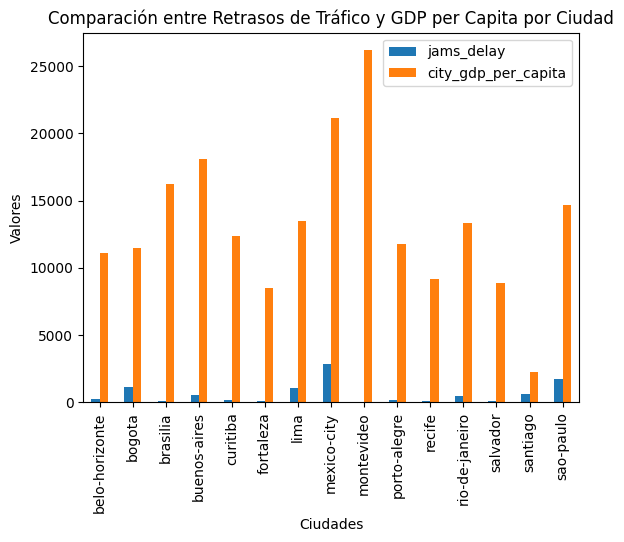

In [ ]:
#Grafico 1 al tener escalas con parametros muy extremos no se aprecia bien la interpretacion de los datos
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
plt.figure(figsize=(15, 8))
merged.plot(kind='bar', x='city', y=['jams_delay', 'city_gdp_per_capita'])
plt.title('Comparación entre Retrasos de Tráfico y GDP per Capita por Ciudad')
plt.xlabel('Ciudades')
plt.ylabel('Valores')
plt.xticks(rotation=90)
plt.show()

# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])


<Figure size 1500x800 with 0 Axes>

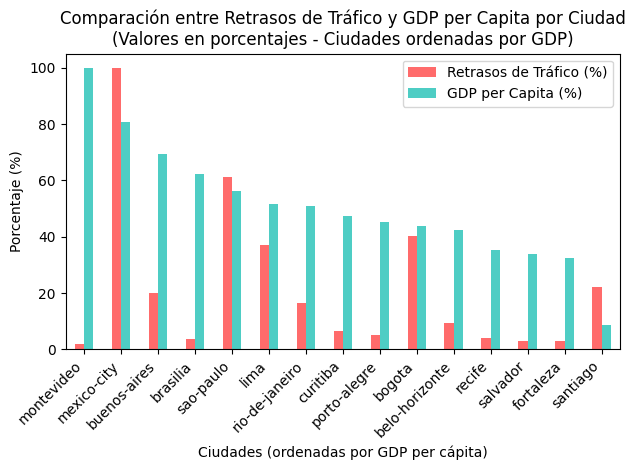

In [ ]:
#Grafico 2 se aprecia mejor la comparacion entre la columna de retrasos y el ingreso per capita por ciudad ademas
#los resultados se muestran en porcentaje y se vuelve visualmenye mas legible

# Paso 1: Ordenar el dataframe por GDP per cápita (mayor a menor)
merged_sorted = merged.sort_values('city_gdp_per_capita', ascending=False)

# Paso 2: Convertir ambas variables a porcentajes (0-100%)
# Normalizar cada variable por su valor máximo
merged_sorted['jams_delay_pct'] = (merged_sorted['jams_delay'] / merged_sorted['jams_delay'].max()) * 100
merged_sorted['gdp_per_capita_pct'] = (merged_sorted['city_gdp_per_capita'] / merged_sorted['city_gdp_per_capita'].max()) * 100

# Paso 3: Crear el gráfico mejorado
plt.figure(figsize=(15, 8))
merged_sorted.plot(kind='bar',
                   x='city',
                   y=['jams_delay_pct', 'gdp_per_capita_pct'],
                   color=['#FF6B6B', '#4ECDC4'])

plt.title('Comparación entre Retrasos de Tráfico y GDP per Capita por Ciudad\n(Valores en porcentajes - Ciudades ordenadas por GDP)')
plt.xlabel('Ciudades (ordenadas por GDP per cápita)')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Retrasos de Tráfico (%)', 'GDP per Capita (%)'])
plt.tight_layout()
plt.show()

Este grafico de barras nos ayuda a a comparar la relacion entre las columnas jamsdelay es decir el tiempo invertido en el trafico con la columna de ingreso per capita por ciudad podemos ver que aunque la cidad de mexico es la que presenta un mayor indice de tiempo invertido en el trafico no mengua la productividad significativamente ya que solo hay un 20% de diferencia entre una variable y otra.

In [ ]:
# Explorar los datos para identificar posibles problemas
print("Estadísticas descriptivas de la tabla merged:")
print(merged[['jams_delay', 'city_gdp_per_capita']].describe())

print("\nCiudades donde jams_delay > city_gdp_per_capita:")
problematic_cities = merged[merged['jams_delay'] > merged['city_gdp_per_capita']]
print(problematic_cities[['city', 'jams_delay', 'city_gdp_per_capita']])


Estadísticas descriptivas de la tabla merged:
        jams_delay  city_gdp_per_capita
count    15.000000            15.000000
mean    629.517204         13253.600000
std     783.063726          5686.213802
min      50.201092          2277.000000
25%     107.165938         10156.500000
50%     263.047879         12381.000000
75%     841.079053         15477.000000
max    2833.057892         26176.000000

Ciudades donde jams_delay > city_gdp_per_capita:
Empty DataFrame
Columns: [city, jams_delay, city_gdp_per_capita]
Index: []


**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

La visualización de los datos me parece correcta, podemos ver los distintos patrones en cada una de las ciudades lo cual es bastante útil para hacer hallazgos interesantes
</div>


### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios: En algunos casos como ciudad de mexico si se representa de esta manera a mayor congestion tambien hay mayor PIB aumenta la congestion de la movilidad pero no mengua significativamente la productividad.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información.


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Segun el obejetivo central del análisis que nos lleva a contestar esta pregunta: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- El retraso en el trafico no necesariamente afecta la productividad en ciudades como ciudad de mexico, bogota y sao paolo aunque existe un alto retraso en el trafico tambien existe un crecimiento en el PIB segun el grafico de barras mostrando la comparacion se puede ver que el PIB no se ve drasticamente afectado por la movilidad, en cambio en ciudades como santiago que presenta el menor PIB y un alto porcentaje de retraso se podria inferir que la movilidad si esta afectadodo el PIB, teniendo esto en contexto y comparando las otras ciudades si se ve afectado el PIB por la movilidad.

**Cobertura de datos:**  
- El analisis ocurre especificamente en el periodo del año 2024, en 15 ciudades y en paises solo de america latina, como Mexico, Brazil, Colombia, Argentina y Peru.

**Metodología (alto nivel):**  
- Se limpian y se ordenan los datos dando formatos de nombre y estandarización de columnas por tipo de dato.
- Se filtra por ciudades en un año especifico dentro de los data sets para despues unificarlos en una sola tabla que nos muestra la relacion entre trafico y economia, las columnas city y year son claves ya que nos sirven de union entre los dos data sets.
- Se valida que los datos esten correctos y estadarizados a lo largo del proyecto se dan diferentes visualizaciones incluso calculos estadisticos que nos llevan a mejores conclusiones, hay graficos como boxplots, histogramas y grafica de barras que nos da una mayor vizualizacion de los resultados

**Hallazgos iniciales:**  
- Se puede apreciar que el indice de trafico en ciudades como ciudad de mexico y sao paola rebasa ligeramente el porcentaje de PIB aunque la diferencia no es significativa y esto puede impplicar oportunidades para reducir el trafico y aumentar la productividad. La ciudad de buenos aires presente un alto PIB y bajo indice de trafico y la ciudad de bogota se encuenta equiloibrada entre indice de trafico y PIB.
- A menor indice de trafico mejor productividad PIB
- Se encuentra que la ciudad de santiago requereria de revision ya que hay un bajo PIB y un alto indice de trafico, se deberian evaluar otros factores dentro de la ciudad hay gran diferencia entre el PIB bajo y el alto trafico.

**Recomendaciones**  
Se sugiere que en ciudad de mexico y sao paolo se puede analizar la manera de reducir indice de trafico con la finalidad de incrementar productividad o bien se puede analizar estrategias que aumenten productividad sin que se afecte la movilidad para que no se disparen los indices de trafico y haya un mejor equilibrio.

- La ciudad de santiago represetan el mayor riesgo en cuanto a la relacion entra movilidad y economia ya que existe un alto indice de trafico pero bajo crecimiento PIB se requiere de un analisis mas profundo para revisar que otros factores estan influyendo en el bajo PIB y que ademas estan afectando la movilidad.  


## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un muy buen trabajo al desarrollar este proyecto, las observaciones que has hecho a lo largo del mismo han servido para tomar acción en los pasos posteriores, terminando en resultados positivos.

Los datos utilizados en este proyecto son bastante útiles e interesantes para hacer hallazgos interesantes, ya que son ciudades que conocemos y podemos asimilar de una mejor manera el contexto en el que situa el proyecto.    

Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!    
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
    
</div>